In [10]:

import pandas as pd
import numpy as np

df = pd.read_csv("dataset.csv")

print(df.head())


print(df.shape)


print(df.info())


print(df.columns)


           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810635  42491                   4                 2.50         2920   
1  6762810998  42491                   5                 2.75         2910   
2  6762812605  42491                   4                 2.50         3310   
3  6762812919  42491                   3                 2.00         2710   
4  6762813105  42491                   3                 2.50         2600   

   lot area  number of floors  waterfront present  number of views  \
0      4000               1.5                   0                0   
1      9480               1.5                   0                0   
2     42998               2.0                   0                0   
3      4500               1.5                   0                0   
4      4750               1.0                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \
0                       5  ...    

In [15]:


df.isnull().sum()



df.duplicated().sum()


np.int64(0)

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


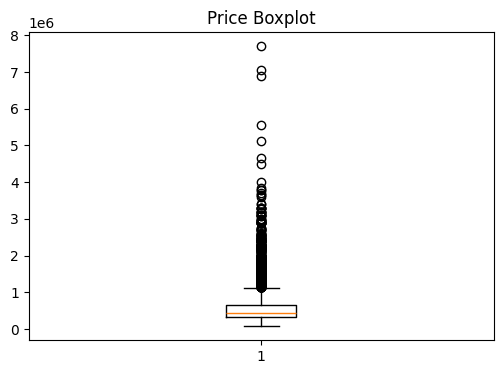

Original Shape: (14619, 23)
After Removing Top 1%: (14472, 23)


In [21]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["Price"])
plt.title("Price Boxplot")
plt.show()


upper_limit = df["Price"].quantile(0.99)

df_clean = df[df["Price"] <= upper_limit]

print("Original Shape:", df.shape)
print("After Removing Top 1%:", df_clean.shape)


import numpy as np

df["Price"] = np.log1p(df["Price"])



In [22]:

X = df.drop("Price", axis=1)
y = df["Price"]


X.select_dtypes(include="object").columns


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)



from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test_scaled)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print("R2 Score:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))




R2 Score: 0.7905759202704803
MAE: 55505.46231785841


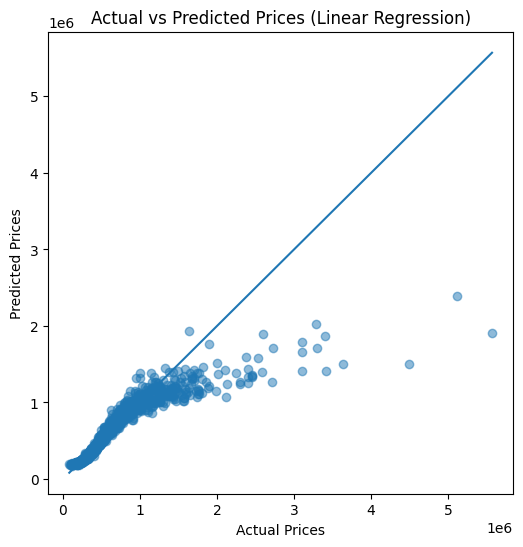

In [24]:


import matplotlib.pyplot as plt
import numpy as np

# Convert back to original price scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

plt.figure(figsize=(6,6))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Linear Regression)")

plt.show()


In [25]:
import joblib

# Save trained model
joblib.dump(model, "house_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature column order
joblib.dump(X.columns, "model_columns.pkl")

print("Model saved successfully ✅")


Model saved successfully ✅


In [26]:


import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# ---------------- LOAD DATA ----------------
df = pd.read_csv("dataset.csv")

# ---------------- SELECT ONLY 7 FEATURES ----------------
features = [
    "number of bedrooms",
    "number of bathrooms",
    "living area",
    "number of floors",
    "grade of the house",
    "Area of the basement",
    "condition of the house"
]

target = "Price"

df = df[features + [target]]

# ---------------- LOG TRANSFORM ----------------
df[target] = np.log1p(df[target])

X = df[features]
y = df[target]

# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------- TRAIN MODEL ----------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ---------------- EVALUATION ----------------
y_pred = model.predict(X_test_scaled)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print("R2 Score:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))

# ---------------- SAVE ----------------
joblib.dump(model, "house_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully ✅")







R2 Score: 0.6516980379042148
MAE: 142476.35294598318
Model saved successfully ✅


In [30]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px

st.set_page_config(page_title="HouseVision AI", layout="wide")

# ---------------- LOAD MODEL ----------------
model = joblib.load("house_model.pkl")
scaler = joblib.load("scaler.pkl")

df = pd.read_csv("dataset.csv")

if "history" not in st.session_state:
    st.session_state.history = []

# ---------------- SIDEBAR ----------------
st.sidebar.title("🏠 HouseVision AI")
page = st.sidebar.radio(
    "Navigation",
    ["Home", "Predict", "Analytics", "History"]
)

# ===================================================
# ===================================================
# HOME
# ===================================================
# ===================================================
# HOME (CyberShield Style Layout)
# ===================================================
if page == "Home":

    st.markdown("""
        <style>
        .hero-title {
            font-size: 48px;
            font-weight: 700;
            margin-bottom: 10px;
        }
        .hero-sub {
            font-size: 18px;
            color: #9aa4b2;
            margin-bottom: 30px;
        }
        .feature-box {
            text-align: center;
            padding: 20px;
        }
        .feature-title {
            font-size: 20px;
            font-weight: 600;
            margin-top: 10px;
        }
        .feature-desc {
            font-size: 14px;
            color: #9aa4b2;
        }
        </style>
    """, unsafe_allow_html=True)

    st.markdown(
        "<div class='hero-title'>🏠 HouseVision AI</div>",
        unsafe_allow_html=True
    )

    st.markdown(
        "<div class='hero-sub'>AI-powered property valuation platform designed to analyze housing features and estimate accurate market prices.</div>",
        unsafe_allow_html=True
    )

    st.markdown("---")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("""
            <div class='feature-box'>
                <div style='font-size:40px;'>📊</div>
                <div class='feature-title'>Smart Price Estimation</div>
                <div class='feature-desc'>
                Uses trained regression models to predict house prices accurately.
                </div>
            </div>
        """, unsafe_allow_html=True)

    with col2:
        st.markdown("""
            <div class='feature-box'>
                <div style='font-size:40px;'>🤖</div>
                <div class='feature-title'>Machine Learning Model</div>
                <div class='feature-desc'>
                Built using cleaned housing data with scaling and transformation.
                </div>
            </div>
        """, unsafe_allow_html=True)

    with col3:
        st.markdown("""
            <div class='feature-box'>
                <div style='font-size:40px;'>📈</div>
                <div class='feature-title'>Interactive Analytics</div>
                <div class='feature-desc'>
                Visualize price distribution and property trends dynamically.
                </div>
            </div>
        """, unsafe_allow_html=True)

    st.markdown("---")

    st.info("👉 Navigate to 'Predict' to estimate house prices instantly.")

# ===================================================
# PREDICT
# ===================================================
elif page == "Predict":

    st.title("🔮 Predict House Price")

    col1, col2 = st.columns(2)

    with col1:
        bedrooms = st.number_input("Number of Bedrooms", 1, 10, 3)
        bathrooms = st.number_input("Number of Bathrooms", 1, 10, 2)
        living_area = st.number_input("Living Area (sq ft)", 200, 10000, 1500)
        floors = st.number_input("Number of Floors", 1, 5, 2)

    with col2:
        grade = st.number_input("Grade of House", 1, 13, 7)
        basement = st.number_input("Basement Area", 0, 5000, 500)
        condition = st.number_input("Condition of House", 1, 5, 3)

    if st.button("Predict Price 🚀"):

        input_data = np.array([[
            bedrooms,
            bathrooms,
            living_area,
            floors,
            grade,
            basement,
            condition
        ]])

        input_scaled = scaler.transform(input_data)

        prediction_log = model.predict(input_scaled)[0]
        prediction = np.expm1(prediction_log)

        st.session_state.history.append(prediction)

        st.success(f"Estimated Price: ₹ {prediction:,.0f}")


2026-02-21 12:09:31.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 12:09:31.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar